In [1]:
import os
from pathlib import Path
import subprocess
import zipfile

DATA_DIR = Path("data/netflix")
DATA_DIR.mkdir(parents=True, exist_ok=True)

csv_path = DATA_DIR / "netflix_titles.csv"

if csv_path.exists():
    print("✅ Found:", csv_path)
else:
    print("netflix_titles.csv not found. Attempting Kaggle download...")
    print("If this fails, use manual download (Option A).")

    # Ensure kaggle is installed
    try:
        import kaggle  # noqa: F401
    except Exception:
        subprocess.check_call([os.sys.executable, "-m", "pip", "install", "-q", "kaggle"])

    # Download dataset zip
    subprocess.check_call(["kaggle", "datasets", "download", "-d", "shivamb/netflix-shows", "-p", str(DATA_DIR)])

    # Unzip all zips in DATA_DIR
    for z in DATA_DIR.glob("*.zip"):
        print("Unzipping:", z.name)
        with zipfile.ZipFile(z, "r") as zip_ref:
            zip_ref.extractall(DATA_DIR)

    print("✅ Done. Files:", [p.name for p in DATA_DIR.glob('*')])


✅ Found: data/netflix/netflix_titles.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

SEED = 0
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

DATA_DIR = Path("data/netflix")
CSV_PATH = DATA_DIR / "netflix_titles.csv"


In [3]:
if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"Missing {CSV_PATH}.\n"
        "Download from Kaggle (manual) or run the Kaggle API download cell above."
    )

df = pd.read_csv(CSV_PATH)
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
def clean_netflix_data(df):
    """
    Cleans the Netflix dataset: handles dates, missing values, and splits multi-value columns.
    """
    # 1. Handle missing values
    df['country'] = df['country'].fillna('Unknown')
    df.dropna(subset=['date_added'], inplace=True)
    
    # 2. Fix date formats
    df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
    df['year_added'] = df['date_added'].dt.year.astype(int)
    
    return df

# Apply custom cleaning function (Required for B1.5)
df = clean_netflix_data(df)

In [ ]:
# Verification of Dataset Dimensions
rows, columns = df.shape
print(f"The dataset contains {rows} rows and {columns} columns.")

# Check if it meets the minimum requirements
if rows >= 100 and columns >= 4:
    print("Requirement satisfied: Dataset meets minimum size requirements.")

The dataset contains 8797 rows and 14 columns.
Requirement B0 satisfied: Dataset meets minimum size requirements.


In [6]:
df.columns.tolist()


['show_id',
 'type',
 'title',
 'director',
 'cast',
 'country',
 'date_added',
 'release_year',
 'rating',
 'duration',
 'listed_in',
 'description',
 'year_added']

In [7]:
df.info()

<class 'pandas.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8797 non-null   str           
 1   type          8797 non-null   str           
 2   title         8797 non-null   str           
 3   director      6173 non-null   str           
 4   cast          7972 non-null   str           
 5   country       8797 non-null   str           
 6   date_added    8797 non-null   datetime64[us]
 7   release_year  8797 non-null   int64         
 8   rating        8793 non-null   str           
 9   duration      8794 non-null   str           
 10  listed_in     8797 non-null   str           
 11  description   8797 non-null   str           
 12  year_added    8797 non-null   int64         
dtypes: datetime64[us](1), int64(2), str(10)
memory usage: 962.2 KB


In [8]:
df.isna().sum().sort_values(ascending=False).head(12)

director        2624
cast             825
rating             4
duration           3
show_id            0
type               0
title              0
country            0
date_added         0
release_year       0
listed_in          0
description        0
dtype: int64

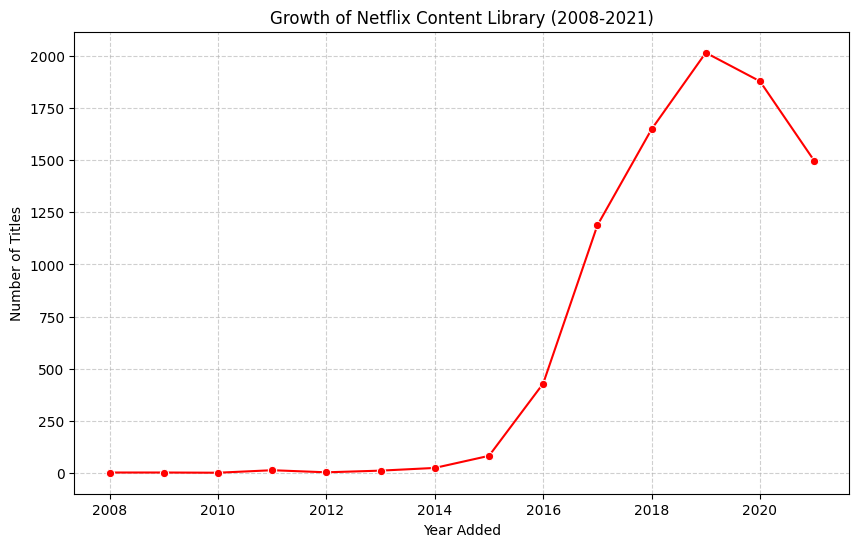

In [ ]:
# Grouped summary: titles per year
titles_per_year = df.groupby('year_added').size()

plt.figure(figsize=(10, 6))
sns.lineplot(x=titles_per_year.index, y=titles_per_year.values, marker='o', color='red')
plt.title('Growth of Netflix Content Library (2008-2021)')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

/var/folders/wc/rp2tl8v5473127_8wlgthnyr0000gn/T/ipykernel_41618/4148247227.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


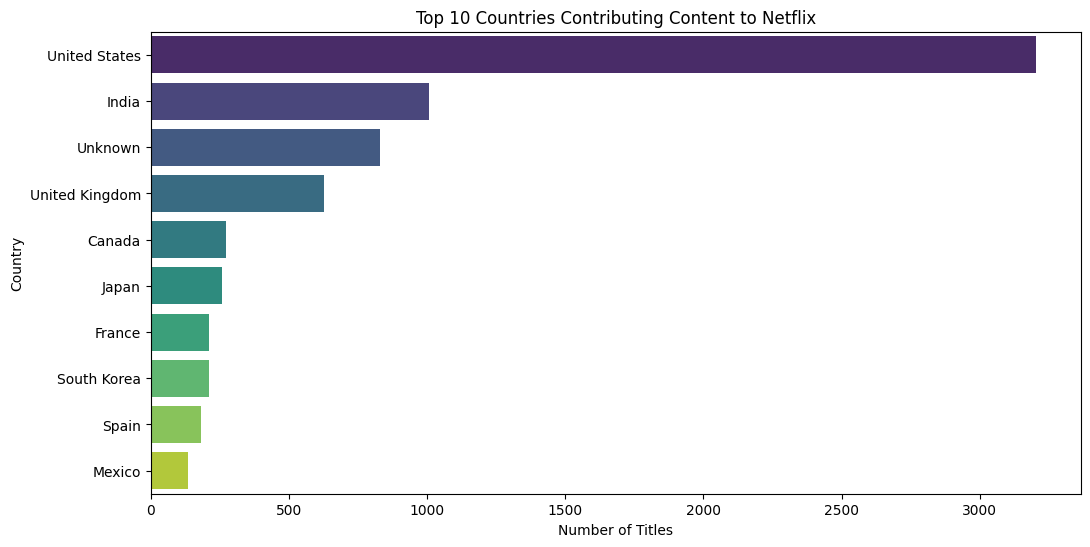

In [ ]:
# Relationship: Comparing top 10 countries
df['primary_country'] = df['country'].apply(lambda x: x.split(',')[0])
top_countries = df['primary_country'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries Contributing Content to Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

In [11]:
print("If you reached this cell after Restart & Run All, your notebook is reproducible.")


If you reached this cell after Restart & Run All, your notebook is reproducible.
